In [48]:

import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import sys, pathlib, os
import pickle
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
import warnings

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

PROJECTS_DIR = pathlib.Path(os.getcwd()).resolve().parents[1]   # .../Proyectos

#  Añadimos a sys.path sólo si no está
if str(PROJECTS_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECTS_DIR))
    
from Efectividad_Nirse.Code.preproces_prod3 import *

def son_similares(cadena1, cadena2):
    return SequenceMatcher(None, cadena1, cadena2).ratio()

path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'
path_eff_data = path_actual.parent.parent / 'Efectividad_Nirse' / 'Data'

new = pd.read_csv(path_data / '2025-04-22_Egresos2024.csv',encoding= 'latin1', sep = '|')#pd.read_csv(path_data / '2024-12-16_Egresos.csv',encoding= 'latin1', sep = '|')
new_2025 = pd.read_csv(path_data / '2026-03-17_Egresos2025.csv',encoding= 'latin1', sep = '|') # 2025-08-18_Egresos2025 este archivo anda bien 
egresos = pd.read_csv(path_data / "egresos.csv",encoding = "latin1",sep="|")

egresos = pd.concat([egresos,new,new_2025])
runes_raros = ['db97ccd245df4a064b20e703623e43804e14dce53f3bb5befb947e0803dd6fd0','ad9e5f32c7e34b52e22b5778b45bd95476c79bed20c550712e75fb43e409085c'] # SON 2 WEONES HIGH RISK DE LA ALEMNA SANTIAGO CON COMUNA INCORRECTA
egresos.loc[egresos.RUT.isin(runes_raros),'COMUNA'] = 13114.0

# file = path_data / "tributacion_egresos hospitalarios_2025.xlsx"

# trib_publi = pd.read_excel(
#     file,
#     sheet_name="EstadoCargaIEEH_SS",  
#     skiprows=0
# )

# trib_priv = pd.read_excel(
#     file,
#     sheet_name="EstadoCargaIEEH_SEREMI",
#     skiprows=0
# )

# trib = pd.concat([trib_publi,trib_priv])

trib_publi = pd.read_excel(
    path_data / "EstadoCargaIEEH_2025_ss.xlsx",
    # sheet_name="EstadoCargaIEEH_SS",  
    skiprows=0
)

trib_priv = pd.read_excel(
    path_data / "EstadoCargaIEEH_2025_seremi.xlsx",
    # sheet_name="EstadoCargaIEEH_SEREMI",
    skiprows=0
)

trib = pd.concat([trib_publi,trib_priv])      

In [49]:
trib_publi = pd.read_excel(
    path_data / "EstadoCargaIEEH_2025_ss.xlsx",
    # sheet_name="EstadoCargaIEEH_SS",  
    skiprows=0
)

trib_priv = pd.read_excel(
    path_data / "EstadoCargaIEEH_2025_seremi.xlsx",
    # sheet_name="EstadoCargaIEEH_SEREMI",
    skiprows=0
)

trib = pd.concat([trib_publi,trib_priv])         

In [29]:
#df_pf = pre_filtred(df_name='NAC_RNI_EGRESOS_ENTREGA_ISCI_11_04_2025_encr.csv',lrti_name='LRTI_Flag')

In [50]:
egresos_safe=egresos.copy()

In [3]:
diagnosticos_upc = [406, 412, 415, 405, 411, 414, 310, 311, 312, 320, 323, 324]
areasMB = [401, 402, 403, 404, 407, 408, 409, 410, 413] # area no considerada: 416, 330, 418, que son areas donde ya estaban.

In [32]:
egresos=egresos_safe.copy()

In [14]:
trib.columns

Index(['Servicio de Salud', 'Codigo Establecimiento', 'Nombre Establecimiento',
       'Total', 'Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep',
       'Oct', 'Nov', 'Dic', 'SEREMI de Salud'],
      dtype='object')

In [51]:
trib['CodigoEstablecimiento'] = trib['Codigo Establecimiento']

acusados = trib[trib['Sep'].isna()].CodigoEstablecimiento
acusados = acusados.dropna().astype(int)

diagnosticos_upc = [406, 412, 415, 405, 411, 414, 310, 311, 312, 320, 323, 324]# [406, 412, 415, 405, 411, 414]
areasMB = [401, 402, 403, 404, 407, 408, 409, 410, 413]
cols_diagnostico = ['AREA_FUNC_I','AREAF_1_TRAS', 'AREAF_2_TRAS', 'AREAF_3_TRAS', 'AREAF_4_TRAS', 'AREAF_5_TRAS', 'AREAF_6_TRAS', 'AREAF_7_TRAS', 'AREAF_8_TRAS', 'AREAF_9_TRAS']
tras_date = {'AREA_FUNC_I': 'fechaIng','AREAF_1_TRAS':'fecha_tras_1', 'AREAF_2_TRAS':'fecha_tras_2', 'AREAF_3_TRAS':'fecha_tras_3', 'AREAF_4_TRAS':'fecha_tras_4', 'AREAF_5_TRAS':'fecha_tras_5'
             , 'AREAF_6_TRAS':'fecha_tras_6', 'AREAF_7_TRAS':'fecha_tras_7', 'AREAF_8_TRAS':'fecha_tras_8', 'AREAF_9_TRAS':'fecha_tras_9'}

def obtener_fecha_primer_upc(row):
    for col in cols_diagnostico:
        if row[col] == 1:
            fecha_col = tras_date[col]
            return row[fecha_col]
    return None

egresos['FECHA_NAC'] = pd.to_datetime({'year': egresos['A_NAC'], 'month': egresos['M_NAC'], 'day': egresos['D_NAC']}, format='%Y-%m-%d')
egresos['fechaIng'] = pd.to_datetime({'year': egresos['ANO_ING'], 'month': egresos['MES_ING'], 'day': egresos['DIA_ING']}, format='%Y-%m-%d')
egresos['fechaEgr'] = pd.to_datetime({'year': egresos['ANO_EGR'], 'month': egresos['MES_EGR'], 'day': egresos['DIA_EGR']}, format='%Y-%m-%d')

egresos = egresos.assign(FECHA_NAC=lambda data: pd.to_datetime(data["FECHA_NAC"], format="%Y-%m-%d"),
                         fechaIng=lambda data: pd.to_datetime(data["fechaIng"], format="%Y-%m-%d"))

#e24 = e24[e24.fechaIng <= "2024-04-21"]
elementos = ['J121', 'J205', 'J210','J219', 'B974' ]
#elementos = ["J13X", "G001", "A403", "H661","B953" ,"J860"]
#elementos = ["J13X", "J14X", "J150", "J151","J152" ,"J153","J154", "J155","J156" ,"J157", "G001", "A403", "H661","B953" ,"J860"]

cods_cardio = [
    'Q200', 'Q201', 'Q202', 'Q203', 'Q204', 'Q205', 'Q206',
    'Q210', 'Q211', 'Q212', 'Q213', 'Q214', 'Q218', 'Q219',
    'Q220', 'Q221', 'Q222', 'Q223', 'Q224', 'Q225', 'Q226', 
    'Q230', 'Q231', 'Q232', 'Q233', 'Q234', 'Q238', 'Q239',
    'Q240', 'Q242', 'Q243', 'Q244', 'Q245', 'Q248', 'Q249',
    'Q250', 'Q251', 'Q252', 'Q253', 'Q254', 'Q255', 'Q256', 
    'Q260', 'Q262', 'Q263', 'Q264', 'Q208', 'Q209', 'Q228', 
    'Q257', 'Q258', 'Q259', 'Q229'
]

cods_preterm = ['P070', 'P071', 'P072', 'P073']
diag_col = [col for col in egresos.columns if col.startswith("DIAG")]

egresos['hay_diag_preterm'] = egresos[diag_col].isin(cods_preterm).any(axis=1)

 ########### forma 1
# egresos['hay_diag_cardio'] = egresos[diag_col].isin(cods_cardio).any(axis=1)

 ########### forma 2
season_ranges = [
    (2025, 'pre_season', '2024-10-01', '2025-03-31'),
    (2025, 'in_season', '2025-04-01', '2025-09-30'),
    (2024, 'pre_season', '2023-10-01', '2024-03-31'),
    (2024, 'in_season', '2024-04-01', '2024-09-30'),
    (2023, 'pre_season', '2022-10-01', '2023-03-31'),
    (2023, 'in_season', '2023-04-01', '2023-09-30'),
    (2022, 'pre_season', '2021-10-01', '2022-03-31'),
    (2022, 'in_season', '2022-04-01', '2022-09-30'),
    (2021, 'pre_season', '2020-10-01', '2021-03-31'),
    (2021, 'in_season', '2021-04-01', '2021-09-30'),
    (2020, 'pre_season', '2019-10-01', '2020-03-31'),
    (2020, 'in_season', '2020-04-01', '2020-09-30'),
    (2019, 'pre_season', '2018-10-01', '2019-03-31'),
    (2019, 'in_season', '2019-04-01', '2019-09-30'),
    (2018, 'pre_season', '2017-10-01', '2018-03-31'),
    (2018, 'in_season', '2018-04-01', '2018-09-30')
]

egresos['hay_diag_cardio'] = False
egresos['year_ing'] = egresos.fechaIng.dt.isocalendar().year

# Iterar sobre cada temporada
for year, season, start_date, end_date in season_ranges:
    mask_año = egresos.year_ing == year
    mask_fecha = egresos['FECHA_NAC'].between(start_date, end_date)
    mask_diag = egresos[diag_col].isin(cods_cardio).any(axis=1)

    # Si se cumple la combinación, se asigna True
    egresos.loc[mask_año & mask_fecha & mask_diag, 'hay_diag_cardio'] = True

egresos.drop(columns=['year_ing'], inplace=True)
##############

# lista_ruts_cardio = egresos.query('DIAG1.isin(@cods_cardio)').RUT.unique()
# lista_ruts_preterms = egresos.query('DIAG1.isin(@cods_preterm)').RUT.unique()

lista_ruts_cardio = egresos.query('hay_diag_cardio').RUT.unique()
lista_ruts_preterms = egresos.query('hay_diag_preterm').RUT.unique()

with open(path_eff_data/'lista_ruts_cardio.pkl', 'wb') as f:
    pickle.dump(lista_ruts_cardio, f)
    
with open(path_eff_data/'lista_ruts_preterms.pkl', 'wb') as f:
    pickle.dump(lista_ruts_preterms, f)

##,'DIAG3','DIAG4','DIAG5','DIAG6','DIAG7','DIAG8','DIAG9','DIAG10','DIAG11'
df_filtrado = (
    egresos[egresos[['DIAG1']].isin(elementos).any(axis=1)]
    .assign(card1 = lambda x: x.RUT.isin(lista_ruts_cardio).astype(int),
            preterm = lambda x: x.RUT.isin(lista_ruts_preterms).astype(int))
)
    
comunas = (
    pd.read_excel(path_data/"comunas.xlsx")
    .drop_duplicates()
    .rename(columns = {'C_COM': 'COMUNA','NOM_REG':'NOMBRE_REGION'})
)
df_filtrado = (
    df_filtrado
    .assign(VRS1 = 1)
    .rename(columns={'RUT':'RUN'})
    .merge(comunas,how='left',on ='COMUNA'))


df_filtrado['NOMBRE_REGION'] = df_filtrado['NOMBRE_REGION'].str.replace('Región', '').str.strip().fillna('Ignorada')

df_filtrado = df_filtrado[['RUN', 'FECHA_NAC','card1','preterm', 'fechaIng', 'VRS1','SEXO','NOMBRE_REGION','AREA_FUNC_I', 'ANO_ING','ESTAB',
                           'DIA_1_TRAS', 'MES_1_TRAS', 'ANO_1_TRAS', 'AREAF_1_TRAS',
                            'DIA_2_TRAS', 'MES_2_TRAS', 'ANO_2_TRAS', 'AREAF_2_TRAS', 'DIA_3_TRAS',
                            'MES_3_TRAS', 'ANO_3_TRAS', 'AREAF_3_TRAS', 'DIA_4_TRAS', 'MES_4_TRAS',
                            'ANO_4_TRAS', 'AREAF_4_TRAS', 'DIA_5_TRAS', 'MES_5_TRAS', 'ANO_5_TRAS',
                            'AREAF_5_TRAS', 'DIA_6_TRAS', 'MES_6_TRAS', 'ANO_6_TRAS',
                            'AREAF_6_TRAS', 'DIA_7_TRAS', 'MES_7_TRAS', 'ANO_7_TRAS',
                            'AREAF_7_TRAS', 'DIA_8_TRAS', 'MES_8_TRAS', 'ANO_8_TRAS',
                            'AREAF_8_TRAS', 'DIA_9_TRAS', 'MES_9_TRAS', 'ANO_9_TRAS',
                            'AREAF_9_TRAS','DIAS_ESTAD','fechaEgr']]
df_filtrado=(df_filtrado
             .assign(age=lambda x: ((x['fechaIng'] - x['FECHA_NAC']).dt.days / 28))
             .query("age <= 48")  ###########################################
)

# df_filtrado=(df_filtrado
#              .assign(age=lambda x: ((x['fechaIng'] - x['FECHA_NAC']).dt.days / 365))
#              .query("4 < age <= 14")  ###########################################
# )



e24 = df_filtrado[df_filtrado.ANO_ING ==2025]
dataprev = df_filtrado[df_filtrado.ANO_ING !=2025]

e24.to_csv(path_data/"egresos2025.csv")
dataprev.to_csv(path_data/"dataprev.csv")
df_filtrado.to_csv(path_data/"full_data.csv")

###################################################################################################################################################################

data = (
    pd.read_csv(path_data/"full_data.csv")[['RUN', 'FECHA_NAC','fechaEgr', 'fechaIng','age']]
    .assign(FECHA_NAC=lambda data: pd.to_datetime(data["FECHA_NAC"], format="%Y-%m-%d"))
    .assign(fechaIng=lambda data: pd.to_datetime(data["fechaIng"], format="%Y-%m-%d"))
    .assign(fechaEgr=lambda data: pd.to_datetime(data["fechaEgr"], format="%Y-%m-%d"))
    .assign(epiweek=lambda x: x['fechaIng'].dt.isocalendar().week)
    .assign(year=lambda x: x['fechaIng'].dt.isocalendar().year)
    .drop_duplicates(subset=['RUN','fechaIng'], keep='first')
)

catchup25 =( 
    data.query("'2024-10-01' <= FECHA_NAC <= '2025-03-31' ")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2025)
)
inseason25 = (
    data.query("'2025-04-01' <= FECHA_NAC <= '2025-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2025)
)

catchup24 =( 
    data.query("'2023-10-01' <= FECHA_NAC <= '2024-03-31' ")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2024)
)
inseason24 = (
    data.query("'2024-04-01' <= FECHA_NAC <= '2024-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2024)
)

catchup23 =( 
    data.query("'2022-10-01' <= FECHA_NAC <= '2023-03-31' ")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2023)
)
inseason23 = (
    data.query("'2023-04-01' <= FECHA_NAC <= '2023-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2023)
)

catchup22 =( 
    data.query("'2021-10-01' <= FECHA_NAC <= '2022-03-31'")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2022)
)
inseason22 = (
    data.query("'2022-04-01' <= FECHA_NAC <= '2022-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2022)
)

####################################################################################################################################################################
catchup21=( 
    data.query("'2020-10-01' <= FECHA_NAC <= '2021-03-31' ")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2021)
)
inseason21 = (
    data.query("'2021-04-01' <= FECHA_NAC <= '2021-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2021)
)

catchup20=( 
    data.query("'2019-10-01' <= FECHA_NAC <= '2020-03-31' ")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2020)
)
inseason20 = (
    data.query("'2020-04-01' <= FECHA_NAC <= '2020-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2020)
)

catchup18=( 
    data.query("'2017-10-01' <= FECHA_NAC <= '2018-03-31' ")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2018)
)
inseason18 = (
    data.query("'2018-04-01' <= FECHA_NAC <= '2018-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2018)
)

####################################################################################################################################################################
catchup19=( 
    data.query("'2018-10-01' <= FECHA_NAC <= '2019-03-31' ")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2019)
)
inseason19 = (
    data.query("'2019-04-01' <= FECHA_NAC <= '2019-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2019)
)

#merge seasons
seasons = pd.concat([catchup25,inseason25,catchup24,inseason24,catchup23,inseason23,catchup22,inseason22,
                     catchup21,inseason21,catchup20,inseason20,
                     catchup19,inseason19,catchup18,inseason18,
                     ])[['RUN','fechaIng','season','elegibilidad']]

df = (
    data
    .merge(seasons, how='left', on=['RUN','fechaIng'])
    .assign(elegibilidad = lambda x: x['elegibilidad'].fillna(0),
            season = lambda x: x['season'].fillna('nonelegible'))
    )

df_safe=df.copy()

In [52]:
df=df_safe.copy()

In [53]:
areasMB = [401, 402, 403, 404, 407, 408, 409, 410, 413]
#merge egresos
egresosprev = pd.read_csv(path_data/'dataprev.csv')
egresos24 = pd.read_csv(path_data/"egresos2025.csv")

egresosprev['fechaIng'] = pd.to_datetime(egresosprev['fechaIng'], format='%Y-%m-%d')
egresos24['fechaIng'] = pd.to_datetime(egresos24['fechaIng'], format='%Y-%m-%d')
egresosprev['fechaEgr'] = pd.to_datetime(egresosprev['fechaEgr'], format='%Y-%m-%d')
egresos24['fechaEgr'] = pd.to_datetime(egresos24['fechaEgr'], format='%Y-%m-%d')

for i in range(1, 10):
    year_col = f'ANO_{i}_TRAS'
    month_col = f'MES_{i}_TRAS'
    day_col = f'DIA_{i}_TRAS'
    date_col = f'fecha_tras_{i}'

    # Combinar las columnas de año, mes y día en una columna de fecha
    egresosprev[date_col] = pd.to_datetime({'year': egresosprev[year_col], 'month': egresosprev[month_col], 'day': egresosprev[day_col]}, format='%Y-%m-%d')
    egresos24[date_col] = pd.to_datetime({'year': egresos24[year_col], 'month': egresos24[month_col], 'day': egresos24[day_col]}, format='%Y-%m-%d')

new_cols_diagnostico = []

for col in cols_diagnostico:
    new_col = f'new_{col}'
    egresosprev[new_col] = egresosprev[col].copy()
    egresos24[new_col] = egresos24[col].copy()
    new_cols_diagnostico.append(new_col)

for col in cols_diagnostico:
    egresosprev[col] = egresosprev[col].apply(lambda x: 1 if x in diagnosticos_upc else 0)
    egresos24[col] = egresos24[col].apply(lambda x: 1 if x in diagnosticos_upc else 0)

for new_col in new_cols_diagnostico:
    egresosprev[new_col] = egresosprev[new_col].apply(lambda x: 1 if x in areasMB else 0)
    egresos24[new_col] = egresos24[new_col].apply(lambda x: 1 if x in areasMB else 0)



egresosprev = (
    egresosprev
    .assign(cama_basica = lambda x: np.where(x[new_cols_diagnostico].eq(1).any(axis=1), 'MB', ""))
    .assign(cama = lambda x: np.where(x[cols_diagnostico].eq(1).any(axis=1), 'UPC', ""))
    .assign(critico = lambda x: np.where(x[cols_diagnostico].eq(1).any(axis=1), 1, 0))
    .assign(ingreso_UPC = lambda x: x.apply(obtener_fecha_primer_upc, axis=1))
)

egresos24 = (
    egresos24
    .assign(cama_basica = lambda x: np.where(x[new_cols_diagnostico].eq(1).any(axis=1), 'MB', ""))
    .assign(cama = lambda x: np.where(x[cols_diagnostico].eq(1).any(axis=1), 'UPC', ""))
    .assign(critico = lambda x: np.where(x[cols_diagnostico].eq(1).any(axis=1), 1, 0))
    .assign(ingreso_UPC = lambda x: x.apply(obtener_fecha_primer_upc, axis=1))
)

# egresosprev['cama'] = np.where(egresosprev[cols_diagnostico].eq(1).any(axis=1), 'UPC', "")
# egresosprev['critico'] = np.where(egresosprev[cols_diagnostico].eq(1).any(axis=1), 1, 0)
# egresosprev['ingreso_UPC'] = egresosprev.apply(obtener_fecha_primer_upc, axis=1)
# egresos24['critico'] = np.where(egresos24[cols_diagnostico].eq(1).any(axis=1), 1, 0)
# egresos24['cama'] = np.where(egresos24[cols_diagnostico].eq(1).any(axis=1), 'UPC', "")
# egresos24['ingreso_UPC'] = egresos24.apply(obtener_fecha_primer_upc, axis=1)


egresos = pd.concat([egresosprev, egresos24], ignore_index=True)

# Aplicar la transformación
egresos = (egresos
           .sort_values('fechaIng')
           #.drop_duplicates(subset=['RUN','fechaIng'], keep='first')
           ) 


egresos = egresos[['RUN','NOMBRE_REGION','SEXO','card1','preterm','cama','cama_basica','ingreso_UPC','critico','fechaIng','ESTAB','fecha_tras_1'
                   ,'fecha_tras_2','fecha_tras_3','fecha_tras_4','fecha_tras_5','fecha_tras_6','fecha_tras_7','fecha_tras_8'
                   ,'fecha_tras_9','DIAS_ESTAD','fechaEgr','AREAF_1_TRAS','AREAF_2_TRAS','AREAF_3_TRAS','AREAF_4_TRAS',
                   'AREAF_5_TRAS','AREAF_6_TRAS','AREAF_7_TRAS','AREAF_8_TRAS','AREAF_9_TRAS','AREA_FUNC_I'] + new_cols_diagnostico]

df = df.merge(egresos, how = 'left', on = ['RUN','fechaIng','fechaEgr'])   ##########agregé egreso#####################

regiones = {
'Metropolitana de Santiago': 'METROPOLITANA',
'De Los Lagos': 'LOS LAGOS',
'De Valparaíso': 'VALPARAISO',
'Extranjero': 'EXTRANJERO',
'De Tarapacá': 'TARAPACA',
'Del Maule': 'MAULE',
'De Ñuble': 'NUBLE',
'Del Bíobío': 'BIOBIO',
"Del Libertador B. O'Higgins": "O'HIGGINS",
'De La Araucanía': 'ARAUCANIA',
'De Aisén del Gral. C. Ibáñez del Campo': 'AISEN',
'De Coquimbo': 'COQUIMBO',
'De Arica y Parinacota': 'ARICA Y PARINACOTA',
'De Antofagasta': 'ANTOFAGASTA',
'De Magallanes y de La Antártica Chilena': 'MAGALLANES Y ANTARTICA',
'De Los Ríos': 'LOS RIOS',
'Ignorada' : None,
'De Atacama': 'ATACAMA'
}

cache={}
L=[]

def mapear_region(region, regiones_dict):
    if type(region) != str:
        return None
    if region in cache:  # Revisar si ya está en caché
        L.append(f"{region}---->{cache[region]}")
        return cache[region]

    mejor_similitud = 0
    mejor_region = None
    for key, value in regiones_dict.items():
        similitud = SequenceMatcher(None, region, key).ratio()
        if similitud > mejor_similitud:
            mejor_similitud = similitud
            mejor_region = value

    resultado = mejor_region if mejor_similitud > 0 else None
    cache[region] = resultado
    L.append(f"{region}---->{resultado}")
    return resultado

df['NOMBRE_REGION'] = df['NOMBRE_REGION'].apply(lambda x: mapear_region(x, regiones))

print(np.unique(L))

region_a_macrozona = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",  # Atacama se cubre con Tarapacá
    "COQUIMBO": "Macrozona Centro",  # Coquimbo se cubre con Valparaíso
    "VALPARAISO": "Macrozona Centro",
    "METROPOLITANA": "Macrozona METROPOLITANA",
    "O'HIGGINS": "Macrozona Centro Sur",
    "MAULE": "Macrozona Centro Sur",  # Maule se cubre con Biobío
    "NUBLE": "Macrozona Centro Sur",
    "BIOBIO": "Macrozona Centro Sur",
    "ARAUCANIA": "Macrozona Sur",  # Araucanía se cubre con Los Ríos y Los Lagos
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"#,

} 

df['Macrozona'] = df['NOMBRE_REGION'].map(region_a_macrozona)

region_a_macrozona2 = {
    "ARICA Y PARINACOTA": "Norte",
    "TARAPACA": "Norte",
    "ANTOFAGASTA": "Norte",
    "ATACAMA": "Norte",  # Atacama se cubre con Tarapacá
    "COQUIMBO": "Centro",  # Coquimbo se cubre con Valparaíso
    "VALPARAISO": "Centro",
    "METROPOLITANA": "Centro",
    "O'HIGGINS": "Centro",
    "MAULE": "Centro",  # Maule se cubre con Biobío
    "NUBLE": "Centro",
    "BIOBIO": "Centro",
    "ARAUCANIA": "Sur",  # Araucanía se cubre con Los Ríos y Los Lagos
    "LOS RIOS": "Sur",
    "LOS LAGOS": "Sur",
    "AISEN": "Sur",
    "MAGALLANES Y ANTARTICA": "Sur"#,
} 

region_to_macrozone_agencia = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",
    "COQUIMBO": "Macrozona Centro Norte",
    "VALPARAISO": "Macrozona Centro Norte",
    "METROPOLITANA": "Macrozona Centro Norte",
    "O'HIGGINS": "Macrozona Centro Norte",
    "MAULE": "Macrozona Centro Sur",
    "NUBLE": "Macrozona Centro Sur",
    "BIOBIO": "Macrozona Centro Sur",
    "ARAUCANIA": "Macrozona Centro Sur",
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"
}

leo_zonas_rename_eng = {'Macrozona Centro Sur':'South Macrozone',
                    'Macrozona Sur':'South Macrozone',
                    'Macrozona Norte':'North Macrozone',
                    'Macrozona Centro Norte':'Central Macrozone',
                    'Macrozona Austral':'Austral Macrozone'}

leo_zonas_rename = {'Macrozona Centro Sur':'Sur',
                    'Macrozona Sur':'Sur',
                    'Macrozona Norte':'Norte',
                    'Macrozona Centro Norte':'Centro',
                    'Macrozona Austral':'Austral'}

df['Macrozona2'] = df['NOMBRE_REGION'].map(region_to_macrozone_agencia).replace(leo_zonas_rename) # ANTES SE USO REGION_A_MACROZONA2 LO CAMBIÉ HOY 28/04/2025

sex = {'2':'Female','1':'Male','3':'intersex','99':'Unknown'}

df = (
    df
    .dropna(subset=['NOMBRE_REGION','SEXO','elegibilidad'])
    .assign(SEXO = lambda x: x.SEXO.fillna(99).astype(int).astype(str).map(sex),
            age = lambda x: x.age.astype(int),
            VRS1 = 1,
            epiweekupc = lambda x: x['ingreso_UPC'].dt.isocalendar().week.fillna(-1).astype(int),
            elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_seson', np.where(x.elegibilidad + 1 == x.year , 'second_season', 'discart'))
            )
    .rename(columns ={'NOMBRE_REGION':'region','SEXO':'sex'})
    .query('(sex=="Female") | (sex=="Male")')
    .drop_duplicates()
)


# df = df.rename(columns ={'NOMBRE_REGION':'region','SEXO':'sex'})
# df=df.dropna(subset=['region','sex','elegibilidad'])
# df["epiweekupc"] = df['ingreso_UPC'].dt.isocalendar().week.fillna(-1).astype(int)
# df = df.drop_duplicates()
# df['VRS1'] = 1

df_acusados = df[df['ESTAB'].isin(acusados)]

trib['trib_suf'] = trib['Sep'] < 0.8 * trib['Ago']
df_trib = trib[~trib['CodigoEstablecimiento'].isna()]
acusados_2 = df_trib[df_trib.trib_suf].CodigoEstablecimiento

df_sintribu=df.copy()
df = df[~df['ESTAB'].isin(acusados)]
df = df[~df['ESTAB'].isin(acusados_2)]

df = df.query('(year < 2025) | (year==2025) ') # (year==2025 & epiweek<=29 & epiweekupc<=29)
df_sintribu = df_sintribu.query('(year < 2025) | (year==2025) ') # & epiweek<=33 & epiweekupc<=33 & epiweek<=40 & epiweekupc<=40
df.to_csv(path_data/"data.csv")
df_sintribu.to_csv(path_data/"data_sintrib.csv")
(df[df.year!=2018]
 .groupby(['year','epiweek','VRS1','elegibilidad','critico'],as_index=False)[['RUN']]
 .count()
 .rename(columns={'RUN':'Count'})
 .to_csv(path_data/'data_download.csv'))


['De Antofagasta---->ANTOFAGASTA'
 'De Arica Parinacota---->ARICA Y PARINACOTA' 'De Atacama---->ATACAMA'
 'De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'De Coquimbo---->COQUIMBO' 'De La Araucanía---->ARAUCANIA'
 'De Los Lagos---->LOS LAGOS' 'De Los Ríos---->LOS RIOS'
 'De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'De Tarapacá---->TARAPACA' 'De Valparaíso---->VALPARAISO'
 'De los Ríos---->LOS RIOS' 'De Ñuble---->NUBLE' 'Del Bíobío---->BIOBIO'
 "Del Libertador Gral. B. O'Higgins---->O'HIGGINS" 'Del Maule---->MAULE'
 'Ignorada---->None' 'Metropolitana de Santiago---->METROPOLITANA']


In [35]:
df_sintribu.query('RUN.isin(@runes_raros)')

,RUN,FECHA_NAC,fechaEgr,fechaIng,age,epiweek,year,season,elegibilidad,region,sex,card1,preterm,cama,cama_basica,ingreso_UPC,critico,ESTAB,fecha_tras_1,fecha_tras_2,fecha_tras_3,fecha_tras_4,fecha_tras_5,fecha_tras_6,fecha_tras_7,fecha_tras_8,fecha_tras_9,DIAS_ESTAD,AREAF_1_TRAS,AREAF_2_TRAS,AREAF_3_TRAS,AREAF_4_TRAS,AREAF_5_TRAS,AREAF_6_TRAS,AREAF_7_TRAS,AREAF_8_TRAS,AREAF_9_TRAS,AREA_FUNC_I,new_AREA_FUNC_I,new_AREAF_1_TRAS,new_AREAF_2_TRAS,new_AREAF_3_TRAS,new_AREAF_4_TRAS,new_AREAF_5_TRAS,new_AREAF_6_TRAS,new_AREAF_7_TRAS,new_AREAF_8_TRAS,new_AREAF_9_TRAS,Macrozona,Macrozona2,VRS1,epiweekupc,elegibilidad_inyear
44442,db97ccd245df4a064b20e703623e43804e14dce53f3bb5befb947e0803dd6fd0,2024-02-09,2024-05-28,2024-05-21,3,21,2024,pre_season,2024.0,METROPOLITANA,Male,1,0,,MB,NaT,0,112200,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,7.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,Macrozona METROPOLITANA,Centro,1,-1,first_seson
46109,ad9e5f32c7e34b52e22b5778b45bd95476c79bed20c550712e75fb43e409085c,2023-12-23,2024-06-25,2024-06-24,6,26,2024,pre_season,2024.0,METROPOLITANA,Male,0,1,,MB,NaT,0,112200,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,1.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,Macrozona METROPOLITANA,Centro,1,-1,first_seson


In [19]:
df.region.unique()

array(["O'HIGGINS", 'BIOBIO', 'ATACAMA', 'AISEN', 'COQUIMBO', 'LOS LAGOS',
       'LOS RIOS', 'ANTOFAGASTA', 'NUBLE', 'METROPOLITANA', 'VALPARAISO',
       'MAGALLANES Y ANTARTICA', 'MAULE', 'ARAUCANIA',
       'ARICA Y PARINACOTA', 'TARAPACA'], dtype=object)

In [10]:
lista_ruts_no_mb = df_sintribu.query('cama_basica!="MB"').RUN.unique()

In [23]:
df.sex.unique()

array(['Female', 'Male', 'Unknown', 'intersex'], dtype=object)

In [22]:
df.sex.value_counts()

sex
Male        22022
Female      16861
intersex        4
Unknown         2
Name: count, dtype: int64

In [8]:
ruts_asex = df.query('sex.isna()').RUN.unique()

In [24]:
df_sintribu.query('year==2025 & epiweek>=14').epiweek.value_counts()

epiweek
17    13
14    10
15     6
16     5
19     1
Name: count, dtype: Int64

In [ ]:
with open(path_data/'ruts_df_f_vrs_preterms.pkl', 'rb') as f:
    ruts_df_f_vrs_prematuro = pickle.load(f)

In [13]:
hospitales_eliminados = df_sintribu[~df_sintribu.isin(df.ESTAB.unique())].ESTAB.unique()

In [14]:
hospitales_eliminados

array([    nan, 112107., 107206., 126204., 124145., 125103., 118107.,
       103218., 105102., 115206., 115221., 112211., 107223., 116112.,
       129101., 116102., 116109., 116107., 116111., 116110., 102201.,
       103220., 105208., 121115., 112102., 119208., 128110., 116108.,
       116105., 124210., 112261., 111200., 112243., 111276., 103103.,
       201288., 117204., 125104.])

In [14]:
df.query('year!=2018 & year!=2020 & year!=2021').assign(elegibilidad_inyear = lambda x: (x.elegibilidad == x.year).astype(int)).groupby(['elegibilidad_inyear','year']).VRS1.size().unstack()

year,2019,2022,2023,2024
elegibilidad_inyear,,,,
0,4391,2457,4235,2973
1,8478,5161,6750,1335


In [292]:
def columna_ratio(df,ano):
    df = (
        df
        .query('year!=2020 & (29>=epiweek>=14)')
        .assign(eleg = lambda df: np.where(df.elegibilidad==ano,1,0))
        .groupby(['region','eleg','year','epiweek']).size().fillna(0)
        .groupby(['region','eleg','year']).cumsum()
        .unstack()
        .pipe(lambda df: df.max(axis=1))
        .reset_index() 
        .pivot(index=['region', 'eleg'], columns=['year'], values=0)  
        .reset_index() 
        .pivot(index='region', columns='eleg', values=ano)
        .reset_index()
        .assign(ratio = lambda df: df[1]/df[0])
        )
    return df['ratio']

ratios_regiones = df.copy()

ratios_regiones = (
    ratios_regiones
    .groupby(['region']).size()
    .reset_index()
    .assign(
        ratio_2019=columna_ratio(df, 2019),
        ratio_2022=columna_ratio(df, 2022),
        ratio_2023=columna_ratio(df, 2023),
        ratio_2024=columna_ratio(df, 2024)
        )
    .drop(columns=0)
    .round(2)
)
ratios_regiones.to_csv(path_data/'ratio_eleg_noeleg_regiones.csv')
# ratios_regiones



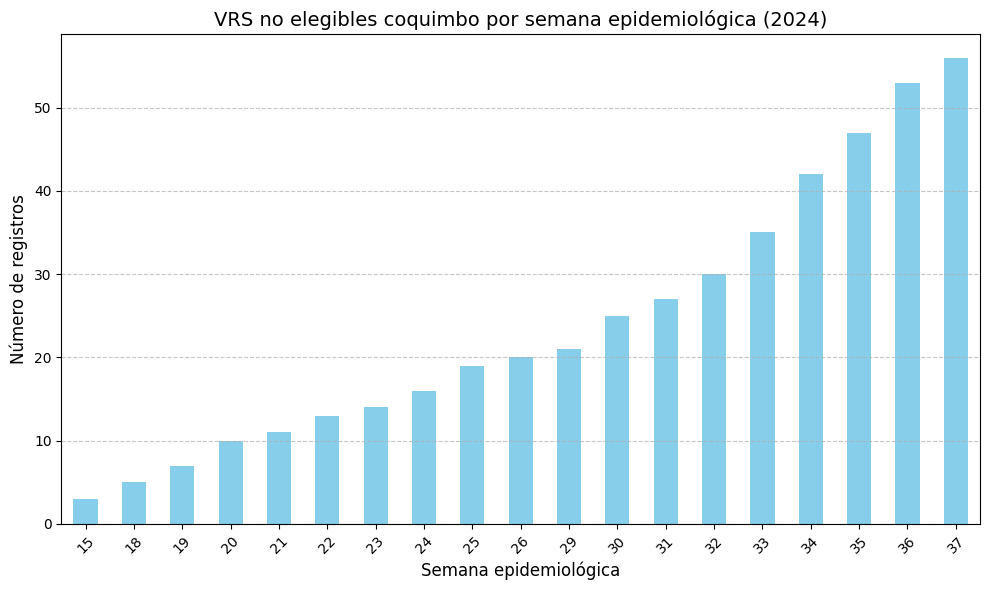

In [21]:
df_grafi = df.query('region=="COQUIMBO" & elegibilidad==2024 & year==2024 & epiweek>=14').groupby('epiweek').size().cumsum()

# Graficar el tamaño por semana epidemiológica
plt.figure(figsize=(10,6))
df_grafi.plot(kind='bar', color='skyblue')

# Personalizar el gráfico
plt.title('VRS no elegibles coquimbo por semana epidemiológica (2024)', fontsize=14)
plt.xlabel('Semana epidemiológica', fontsize=12)
plt.ylabel('Número de registros', fontsize=12)
plt.xticks(rotation=45)  # Rotar etiquetas del eje x si es necesario
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Añadir líneas de rejilla

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [22]:
df_safe_final=df.copy()

In [20]:
df=df_sintribu.copy()

In [21]:
df['days_upc'] = 0
df['dias_en_ing'] = (df['fecha_tras_1'] - df['fechaIng']).apply(lambda x:  1 + x.days if pd.notna(x) else None)
for i in range(1, 10):
    date_col = f'fecha_tras_{i}'
    date_col_next = f'fecha_tras_{i+1}'
    diff = f'dias_en_area_{i}'
    if i==9:
        date_col_next = 'fechaEgr'
    df[diff] = (df[date_col_next] - df[date_col]).apply(lambda x: 1 + x.days if pd.notna(x) else None)
    

df['days_upc'] += df['dias_en_ing'].fillna(0)*df['AREA_FUNC_I']

for i in range(1, 10):
    area_col = f'AREAF_{i}_TRAS'
    diff = f'dias_en_area_{i}'
    df['days_upc'] += df[diff].fillna(0)*df[area_col]

df['days_upc_vrs'] = df['days_upc']

In [ ]:
df.query('elegibilidad==2024').groupby(['year','epiweek']).size()

In [ ]:
(df.query('elegibilidad==2024').#.query('epiweek>=14')
groupby(['season','epiweek'])['fechaIng'].count().unstack(0).cumsum()
)

In [37]:
df.query('0<elegibilidad<2024').query('0<DIAS_ESTAD').groupby(['elegibilidad']).DIAS_ESTAD.mean()

elegibilidad
2019.0    5.276325
2022.0    5.588642
2023.0    5.776487
Name: DIAS_ESTAD, dtype: float64

In [38]:
df.query('0<elegibilidad<2024').query('0<days_upc_vrs').groupby(['elegibilidad']).days_upc_vrs.mean()

elegibilidad
2019.0    6.772049
2022.0    7.517399
2023.0    7.055926
Name: days_upc_vrs, dtype: float64

In [40]:
df.query('0<elegibilidad<2024').query('0<DIAS_ESTAD').groupby(['elegibilidad']).age.mean()

elegibilidad
2019.0    6.292779
2022.0    6.556999
2023.0    3.693535
Name: age, dtype: float64

In [41]:
df.query('0<elegibilidad<2024').query('0<days_upc_vrs').groupby(['elegibilidad']).age.mean()

elegibilidad
2019.0    6.470149
2022.0    6.308614
2023.0    3.316573
Name: age, dtype: float64

In [50]:
grupo_2019 = df.query('0<elegibilidad<2024').query('0<DIAS_ESTAD')[df['elegibilidad'] == 2019]['DIAS_ESTAD']
grupo_2023 = df.query('0<elegibilidad<2024').query('0<DIAS_ESTAD')[df['elegibilidad'] == 2023]['DIAS_ESTAD']

# Realizar el test t de Student para muestras independientes
t_stat, p_value = stats.ttest_ind(grupo_2019, grupo_2023)

# Mostrar los resultados
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación
if p_value < 0.05:
    print("Existe una diferencia significativa entre las medias de los dos grupos.")
else:
    print("No existe una diferencia significativa entre las medias de los dos grupos.")

Estadístico t: -12.7217
Valor p: 0.0000
Existe una diferencia significativa entre las medias de los dos grupos.


C:\Users\ntrig\AppData\Local\Temp\ipykernel_4428\677917098.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  grupo_2019 = df.query('0<elegibilidad<2024').query('0<DIAS_ESTAD')[df['elegibilidad'] == 2019]['days_upc_vrs']
C:\Users\ntrig\AppData\Local\Temp\ipykernel_4428\677917098.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  grupo_2023 = df.query('0<elegibilidad<2024').query('0<DIAS_ESTAD')[df['elegibilidad'] == 2023]['days_upc_vrs']


In [51]:
grupo_2019 = df.query('0<elegibilidad<2024').query('0<days_upc_vrs')[df['elegibilidad'] == 2019]['days_upc_vrs']
grupo_2023 = df.query('0<elegibilidad<2024').query('0<days_upc_vrs')[df['elegibilidad'] == 2023]['days_upc_vrs']
grupo_2019.to_csv(path_data.parent.parent/ 'Efectividad_Nirse' / 'Data' /'grupo_2019.csv',index=False)
grupo_2023.to_csv(path_data.parent.parent/ 'Efectividad_Nirse' / 'Data' /'grupo_2023.csv',index=False)

C:\Users\ntrig\AppData\Local\Temp\ipykernel_4428\4034475744.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  grupo_2019 = df.query('0<elegibilidad<2024').query('0<days_upc_vrs')[df['elegibilidad'] == 2019]['days_upc_vrs']
C:\Users\ntrig\AppData\Local\Temp\ipykernel_4428\4034475744.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  grupo_2023 = df.query('0<elegibilidad<2024').query('0<days_upc_vrs')[df['elegibilidad'] == 2023]['days_upc_vrs']


In [ ]:
# Filtrar los datos
inmunes = df['days_upc_vrs'][(df['inmunizado'] == 1) & (df['days_upc_vrs'] > 0)]
no_inmunes = df['days_upc_vrs'][(df['inmunizado'] == 0) & (df['days_upc_vrs'] > 0)]

# Calcular las medias y tamaños de muestra
media_inmunes = inmunes.mean()
media_no_inmunes = no_inmunes.mean()
n_inmunes = inmunes.count()
n_no_inmunes = no_inmunes.count()

# Calcular la prueba t de Student para muestras independientes
t_stat, p_value = stats.ttest_ind(inmunes, no_inmunes)

# Mostrar las medias y tamaños de muestra
print(f"Media (Inmunizados): {media_inmunes:.2f} (N = {n_inmunes})")
print(f"Media (No inmunizados): {media_no_inmunes:.2f} (N = {n_no_inmunes})")

# Mostrar los resultados de la prueba t
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación
if p_value < 0.05:
    print("Existe una diferencia significativa entre las medias de los dos grupos.")
else:
    print("No existe una diferencia significativa entre las medias de los dos grupos.")

In [40]:
df_all = df_sintribu.copy()
acusados.nunique(), acusados_2.nunique(), acusados.nunique() + acusados_2.nunique()

(41, 45, 86)

In [41]:
mshare_acusados = []
hospital_codes = []
u=0
inter=0
max_estab=0
d_2023_25=df_all[(df_all.year==2023)
                 ]
ntot = d_2023_25.shape[0]
for i in acusados.unique():
    nrow = d_2023_25[d_2023_25['ESTAB'] == i].shape[0]
    hospital_codes.append(i)
    #if nrow==0:
        #mshare_acusados.append(0)
    if u <= nrow/ntot:
        u=nrow/ntot
        max_estab = i
        #mshare_acusados.append(nrow/ntot)
    
    #else:
        #mshare_acusados.append(nrow/ntot)
    mshare_acusados.append(nrow/ntot)

for i in acusados_2.unique():
    if i in acusados.unique():
        print("wow")
        inter=1
    else:
        nrow = d_2023_25[d_2023_25['ESTAB'] == i].shape[0]
        hospital_codes.append(i)
        #if nrow==0:
            #mshare_acusados.append(0)
        if u <= nrow/ntot:
            u=nrow/ntot
            max_estab = i
            #mshare_acusados.append(nrow/ntot)
        #else:
            #mshare_acusados.append(nrow/ntot)
        mshare_acusados.append(nrow/ntot)
            
df_market_share = pd.DataFrame({
    'hospital_code': hospital_codes,
    'market_share': mshare_acusados
})

print("Fueron eliminados el", sum(mshare_acusados)*100, "% de los datos")
if inter==0:
    print("Fueron eliminados", acusados.nunique()+acusados_2.nunique(), "hospitales")
    

Fueron eliminados el 5.410868382181451 % de los datos
Fueron eliminados 86 hospitales


In [12]:
mshare_acusados = []
hospital_codes = []
u=0
inter=0
max_estab=0
d_2023_25=df_all[(df_all.year==2023) & (df_all.epiweek<=29)
                 ]
ntot = d_2023_25.shape[0]
for i in acusados.unique():
    nrow = d_2023_25[d_2023_25['ESTAB'] == i].shape[0]
    hospital_codes.append(i)
    if nrow==0:
        mshare_acusados.append(0)
    elif u <= nrow/ntot:
        u=nrow/ntot
        max_estab = i
        mshare_acusados.append(nrow/ntot)
    else:
        mshare_acusados.append(nrow/ntot)

for i in acusados_2.unique():
    if i in acusados.unique():
        print("wow")
        inter=1
    else:
        nrow = d_2023_25[d_2023_25['ESTAB'] == i].shape[0]
        hospital_codes.append(i)
        if nrow==0:
            mshare_acusados.append(0)
        elif u <= nrow/ntot:
            u=nrow/ntot
            max_estab = i
            mshare_acusados.append(nrow/ntot)
        else:
            mshare_acusados.append(nrow/ntot)
            
df_market_share = pd.DataFrame({
    'hospital_code': hospital_codes,
    'market_share': mshare_acusados
})

print("Fueron eliminados el", sum(mshare_acusados)*100, "% de los datos")
if inter==0:
    print("Fueron eliminados", acusados.nunique()+acusados_2.nunique(), "hospitales")

Fueron eliminados el 14.925373134328362 % de los datos
Fueron eliminados 109 hospitales


In [308]:
df_market_share[df_market_share['market_share']>0.01]['market_share'].sum()

0.1440106477373558

In [309]:
df_market_share[df_market_share['market_share']>=0.01]

,hospital_code,market_share
4,111101.0,0.019255
5,112102.0,0.051020
30,112200.0,0.020142
32,112211.0,0.020674
35,112249.0,0.022272
47,200486.0,0.010648


In [167]:
df.shape[0]/(1-sum(mshare_acusados))

43496.91408114559

In [168]:
(df.shape[0]/(1-sum(mshare_acusados)) -  df.shape[0])/(df.shape[0]/(1-sum(mshare_acusados)))

0.16283716283716287

In [169]:
sum(mshare_acusados)

0.16283716283716285

In [132]:
porcent = (sum(mshare_acusados)/(sum(mshare_acusados)+1))
print(porcent)

0.14003436426116841


In [42]:
df_filtrado = df[(df['fechaIng'] >= '2024-01-01') & (df['fechaIng'] <= '2024-08-31')]

monthly_counts = df_filtrado.groupby('ESTAB').resample('M', on='fechaIng').size().reset_index(name='counts')

df_monthly_counts = pd.DataFrame(monthly_counts)

df_monthly_counts

C:\Users\ntrig\AppData\Local\Temp\ipykernel_184\2669139879.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df_filtrado.groupby('ESTAB').resample('M', on='fechaIng').size().reset_index(name='counts')


,ESTAB,fechaIng,counts
0,102100,2024-03-31,1
1,102100,2024-04-30,5
2,102100,2024-05-31,19
3,102100,2024-06-30,33
4,103100,2024-01-31,2
...,...,...,...
372,201288,2024-04-30,1
373,201288,2024-05-31,2
374,201319,2024-04-30,1
375,201319,2024-05-31,8


In [310]:
for i in acusados.unique():
    if i in acusados_2.unique():
        print(i, "ESTÁ EN LOS 2")

for i in acusados_2.unique():
    if i in acusados.unique():
        print(i, "ESTÁ EN LOS 2")

In [311]:
act_week= df[['year','epiweek']].groupby("year").max()["epiweek"][2024]
print(act_week)

38
